# تحليل المشاعر (Sentiment Analysis) للنصوص العربية باستخدام Deep Learning

**الهدف:** تصنيف النصوص العربية إلى (Positive / Negative / Neutral) باستخدام 5 نماذج مختلفة من الشبكات العصبية العميقة، ومقارنة أداء كل واحد فيهم في الآخر.

**النماذج المستخدمة:**
1. Simple RNN
2. LSTM
3. GRU
4. Bidirectional RNN (BiLSTM)
5. Transformer (Encoder مبني من الصفر)

**ملاحظة هامة:** النوتبوك ده مبني على نفس الداتاست اللي استخدمته قبل كده (`Arabic Sentiment Analysis (1).xlsx`) بعمودين `text` و `sentiment` (القيم: -1 سلبي، 0 محايد، 1 إيجابي). لو اسم الملف أو الأعمدة مختلفة عندك، غيّرها في خلية تحميل الداتا بس.


## 1. تثبيت واستدعاء المكتبات (Setup)

In [14]:
# لو المكتبات مش متثبتة عندك شغل الخلية دي مرة واحدة
!pip install pyarabic nltk tensorflow scikit-learn --quiet


In [15]:
# ==========================================================
# Imports
# ==========================================================
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

# Arabic text processing
import pyarabic.araby as araby
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout,
    Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D,
    Layer
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.20.0
GPU available: False


## 2. تحميل واستكشاف البيانات (Load & Explore Data)

In [16]:
# غيّر اسم الملف هنا لو مختلف عندك
DATA_PATH = 'Arabic Sentiment Analysis .xlsx'

df = pd.read_excel(DATA_PATH)
df.columns = ['text', 'sentiment']

print(f"Shape: {df.shape}")
df.head()


Shape: (32036, 2)


,text,sentiment
0,شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...,-1
1,خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...,1
2,تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...,-1
3,فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...,1
4,سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...,-1


In [17]:
sentiment_map = {-1.0: 'Negative', 0.0: 'Neutral', 1.0: 'Positive'}
df['sentiment_label'] = df['sentiment'].map(sentiment_map)

print("Label distribution:")
print(df['sentiment_label'].value_counts())
print()
print("Percentages:")
print((df['sentiment_label'].value_counts(normalize=True) * 100).round(2))


Label distribution:
sentiment_label
Positive    19189
Negative    11340
Neutral      1507
Name: count, dtype: int64

Percentages:
sentiment_label
Positive    59.9
Negative    35.4
Neutral      4.7
Name: proportion, dtype: float64


In [18]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())


count    32036.000000
mean         9.353571
std         12.461545
min          1.000000
25%          3.000000
50%          5.000000
75%         11.000000
max        374.000000
Name: word_count, dtype: float64


## 3. تصور البيانات (EDA)

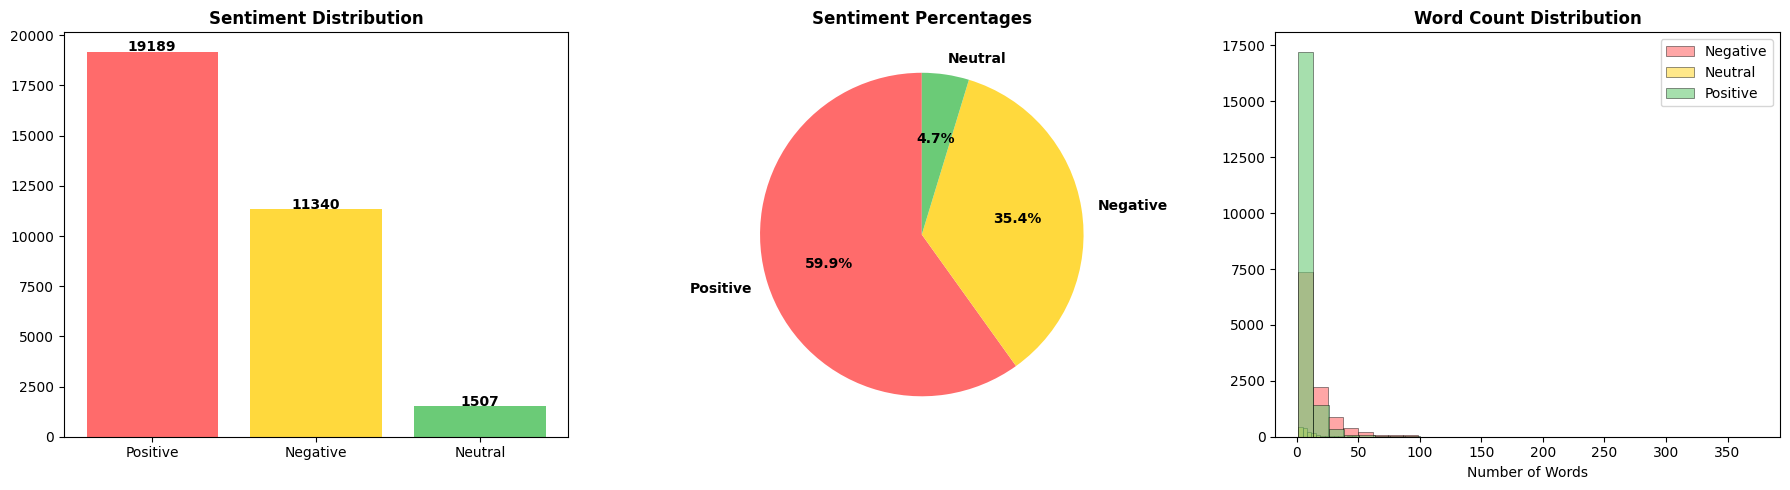

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#FF6B6B', '#FFD93D', '#6BCB77']

# 3.1 Bar chart
counts = df['sentiment_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Sentiment Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3.2 Pie chart
percentages = df['sentiment_label'].value_counts(normalize=True) * 100
axes[1].pie(percentages.values, labels=percentages.index, autopct='%0.1f%%',
            colors=colors, startangle=90, textprops={'fontweight': 'bold'})
axes[1].set_title('Sentiment Percentages', fontweight='bold')

# 3.3 Word count distribution
for sentiment, color in zip(['Negative', 'Neutral', 'Positive'], colors):
    subset = df[df['sentiment_label'] == sentiment]
    axes[2].hist(subset['word_count'], bins=30, alpha=0.6, label=sentiment,
                 color=color, edgecolor='black', linewidth=0.5)
axes[2].set_title('Word Count Distribution', fontweight='bold')
axes[2].set_xlabel('Number of Words')
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. تنظيف النصوص العربية (Arabic Text Preprocessing)

بنطبق نفس الـ pipeline الأساسي: إزالة الروابط، **ترجمة الإيموجي لكلمة عربية بمعناه** (بدل حذفه)، توحيد الحروف (Normalization)، إزالة التشكيل (Tashkeel)، إزالة الإطالة (Tatweel) والتكرار، وإزالة الـ stopwords.

In [20]:
arabic_stopwords = set(stopwords.words('arabic'))

# ------------------------------------------------------------------
# Emoji -> Arabic sentiment word mapping.
# Instead of deleting emojis (and losing a strong sentiment signal),
# we translate the common ones into an Arabic word that carries the
# same sentiment, so it survives the later "keep Arabic only" filter.
# ------------------------------------------------------------------
EMOJI_SENTIMENT_MAP = {
    '😀': ' سعيد ', '😃': ' سعيد ', '😄': ' سعيد ', '😁': ' سعيد ', '😆': ' مرح ',
    '😅': ' مرح ', '🤣': ' ضحك ', '😂': ' ضحك ', '🙂': ' سعيد ', '🙃': ' غريب ',
    '😊': ' سعيد ', '😇': ' سعيد ', '🥰': ' حب ', '😍': ' حب ', '🤩': ' اعجاب ',
    '😘': ' حب ', '😗': ' حب ', '😚': ' حب ', '😙': ' حب ', '😋': ' لذيذ ',
    '😛': ' مرح ', '😜': ' مرح ', '🤪': ' مرح ', '😝': ' مرح ', '🤑': ' مال ',
    '🤗': ' سعيد ', '🤭': ' خجل ', '🤫': ' هادئ ', '🤔': ' تفكير ', '🤐': ' صمت ',
    '😐': ' محايد ', '😑': ' محايد ', '😶': ' محايد ', '😏': ' سخرية ',
    '😒': ' استياء ', '🙄': ' استياء ', '😬': ' توتر ', '🤥': ' كذب ',
    '😌': ' راحة ', '😔': ' حزن ', '😪': ' تعب ', '🤤': ' تعب ', '😴': ' نوم ',
    '😷': ' مرض ', '🤒': ' مرض ', '🤕': ' اذى ', '🤢': ' اشمئزاز ', '🤮': ' اشمئزاز ',
    '🥵': ' حر ', '🥶': ' برد ', '😵': ' دوخة ', '🤯': ' صدمة ', '🤠': ' مرح ',
    '😎': ' ثقة ', '🤓': ' ذكاء ', '🧐': ' تفكير ', '😕': ' حيرة ', '😟': ' قلق ',
    '🙁': ' حزن ', '☹️': ' حزن ', '😮': ' تفاجؤ ', '😯': ' تفاجؤ ', '😲': ' صدمة ',
    '😳': ' احراج ', '🥺': ' حزن ', '😦': ' قلق ', '😧': ' قلق ', '😨': ' خوف ',
    '😰': ' خوف ', '😥': ' حزن ', '😢': ' حزن ', '😭': ' بكاء ', '😱': ' خوف ',
    '😖': ' استياء ', '😣': ' استياء ', '😞': ' حزن ', '😓': ' توتر ', '😩': ' تعب ',
    '😫': ' تعب ', '🥱': ' ملل ', '😤': ' غضب ', '😡': ' غضب ', '😠': ' غضب ',
    '🤬': ' غضب ', '😈': ' شر ', '👿': ' شر ',
    '❤️': ' حب ', '❤': ' حب ', '🧡': ' حب ', '💛': ' حب ', '💚': ' حب ', '💙': ' حب ',
    '💜': ' حب ', '🖤': ' حزن ', '🤍': ' حب ', '🤎': ' حب ', '💕': ' حب ',
    '💞': ' حب ', '💓': ' حب ', '💗': ' حب ', '💖': ' حب ', '💘': ' حب ',
    '💝': ' حب ', '💔': ' حزن ',
    '👍': ' موافقة ', '👎': ' رفض ', '👏': ' اعجاب ', '🙌': ' فرح ', '👌': ' موافقة ',
    '✌️': ' سلام ', '🤞': ' تمني ', '🤝': ' اتفاق ', '🙏': ' دعاء ',
    '💪': ' قوة ', '🔥': ' رائع ', '✨': ' رائع ', '🌟': ' رائع ', '⭐': ' رائع ',
    '💯': ' ممتاز ', '💩': ' سيء ', '🎉': ' احتفال ', '🎊': ' احتفال ',
}

def map_emojis(text):
    """Translate known emojis into Arabic sentiment-carrying words."""
    for emoji_char, word in EMOJI_SENTIMENT_MAP.items():
        text = text.replace(emoji_char, word)
    return text

def normalize_arabic_letters(text):
    """Unify different letterforms that represent the same sound."""
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[ؤئ]', 'ء', text)
    return text

def remove_tashkeel(text):
    """Strip Arabic diacritics (Fatha, Damma, Kasra, Sukun, Shadda...)."""
    return araby.strip_tashkeel(text)

def remove_tatweel_and_repeats(text):
    """Remove elongation (tatweel) and reduce 3+ repeated chars to 1."""
    text = araby.strip_tatweel(text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    return text

def remove_noise(text):
    """Strip URLs and mentions, translate known emojis, then drop
    whatever non-Arabic characters remain (unmapped emojis, digits,
    Latin letters, punctuation)."""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = map_emojis(text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return text

def remove_stopwords(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in arabic_stopwords]
    return ' '.join(tokens)

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ''
    text = remove_noise(text)
    text = remove_tashkeel(text)
    text = remove_tatweel_and_repeats(text)
    text = normalize_arabic_letters(text)
    text = remove_stopwords(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning pipeline ready (emojis are now mapped to Arabic sentiment words, not deleted).")


Cleaning pipeline ready (emojis are now mapped to Arabic sentiment words, not deleted).


In [21]:
df['cleaned_text'] = df['text'].apply(clean_arabic_text)

# Remove rows that became empty after cleaning
before = len(df)
df = df[df['cleaned_text'].str.strip() != '']
df = df.reset_index(drop=True)
print(f"Before cleaning: {before} | After cleaning: {len(df)}")

# Sample check
sample_idx = df.sample(3, random_state=42).index
for idx in sample_idx:
    print(f"\nOriginal: {df.loc[idx, 'text']}")
    print(f"Cleaned:  {df.loc[idx, 'cleaned_text']}")


Before cleaning: 32036 | After cleaning: 30998

Original: أكل رائع جدا
Cleaned:  اكل راءع جدا

Original: انصاف كباتن طلبات
Cleaned:  انصاف كباتن طلبات

Original: من 2004 المفروض تطور أكثر من كذا !!   - اضافة تفاصيل المطعم ( الموقع ، ارقام تواصل ، الفروع  ) - منيو مصورة .. سهلة ماتحتاج! نسخه من منيو المطعم يعمل لها نسخ بالسكانر ويرسلها ع ايميلكم   بالتوفيق :)
Cleaned:  المفروض تطور اكثر اضافه تفاصيل المطعم الموقع ، ارقام تواصل ، الفروع منيو مصوره سهله ماتحتاج نسخه منيو المطعم يعمل نسخ بالسكانر ويرسلها ايميلكم بالتوفيق


## 5. ترميز الفئات وتقسيم البيانات (Label Encoding & Train/Test Split)

In [22]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])  # 0,1,2

print("Label mapping:")
for cls, enc in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {sentiment_map[cls]} ({cls}) -> {enc}")

NUM_CLASSES = df['label'].nunique()

X = df['cleaned_text'].values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train_text)} | Test size: {len(X_test_text)}")


Label mapping:
  Negative (-1) -> 0
  Neutral (0) -> 1
  Positive (1) -> 2

Train size: 24798 | Test size: 6200


### معالجة عدم توازن الفئات (Imbalance) بالـ Oversampling

بدل `class_weight` بس، بنعمل **Oversampling حقيقي** هنا: بنكرر عينات الفئات القليلة عشوائيًا لحد ما توازي الفئة الأكبر.

**مهم جدًا:** الـ Oversampling بيتم على `X_train_text` / `y_train` **بعد** الـ split، مش قبله — عشان الـ test set يفضل يمثل التوزيع الحقيقي للبيانات ومفيش أي عينة مكررة تتسرب بين التدريب والاختبار (data leakage).

وبما إننا وازنا الفئات فعليًا بالتكرار، مش هنستخدم `class_weight` كمان في التدريب — استخدام الاتنين مع بعض بيخلي الموديل "يبالغ" في التركيز على الفئة القليلة (تعويض مضاعف).

In [23]:
train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
counts_before = train_df['label'].value_counts()
print("Training distribution BEFORE oversampling:")
print(counts_before)

max_count = counts_before.max()

oversample_ratio = 0.4
balanced_parts = []
for label, count in counts_before.items():
    class_df = train_df[train_df['label'] == label]
    if count < max_count:
        # target = العدد الحالي + نسبة من الفرق بينه وبين أكبر كلاس
        target_count = int(count + (max_count - count) * oversample_ratio)
        class_df = resample(class_df, replace=True, n_samples=target_count, random_state=42)
    balanced_parts.append(class_df)

train_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_text = train_balanced['text'].values
y_train = train_balanced['label'].values

print("\nTraining distribution AFTER mild oversampling:")
print(pd.Series(y_train).value_counts())


class_weights = {c: 1.0 for c in np.unique(y_train)}


Training distribution BEFORE oversampling:
label
2    14708
0     8909
1     1181
Name: count, dtype: int64

Training distribution AFTER mild oversampling:
2    14708
0    11228
1     6591
Name: count, dtype: int64


## 6. Tokenization و Padding (تجهيز البيانات لنماذج الـ Deep Learning)

In [24]:
VOCAB_SIZE = 20000
MAX_LEN = int(df['cleaned_text'].apply(lambda x: len(x.split())).quantile(0.95))
MAX_LEN = max(MAX_LEN, 10)
print(f"MAX_LEN used for padding (95th percentile of word count): {MAX_LEN}")

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

vocab_size_actual = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"Vocabulary size actually used: {vocab_size_actual}")
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")


MAX_LEN used for padding (95th percentile of word count): 27
Vocabulary size actually used: 20000
X_train_pad shape: (32527, 27)
X_test_pad shape:  (6200, 27)


## 7. دوال مساعدة عامة (Training / Evaluation Helpers)

In [25]:
EMBEDDING_DIM = 128
LABELS_ORDER = ['Negative', 'Neutral', 'Positive']  # matches encoded order 0,1,2 (double-check mapping above)

results = {}          # stores metrics for every model
histories = {}        # stores training history for every model
predictions = {}      # stores y_pred for every model

def train_and_evaluate(model, model_name, epochs=15, batch_size=64, use_class_weight=True):
    """Compile-agnostic trainer: expects an already-compiled Keras model."""
    print("=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)

    early_stop = EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )

    history = model.fit(
        X_train_pad, y_train_cat,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights if use_class_weight else None,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\nAccuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\n" + classification_report(y_test, y_pred, target_names=LABELS_ORDER, zero_division=0))

    results[model_name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    histories[model_name] = history
    predictions[model_name] = y_pred

    return model, history

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER)
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print("Helper functions ready.")


Helper functions ready.


## 8. النموذج الأول: Simple RNN

In [26]:
tf.keras.backend.clear_session()

rnn_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
rnn_model, rnn_history = train_and_evaluate(rnn_model, 'Simple RNN')


Training: Simple RNN
Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.7302 - loss: 0.6668 - val_accuracy: 0.8607 - val_loss: 0.3868
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9082 - loss: 0.2848 - val_accuracy: 0.9038 - val_loss: 0.2838
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9468 - loss: 0.1733 - val_accuracy: 0.9056 - val_loss: 0.2800
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9580 - loss: 0.1396 - val_accuracy: 0.9109 - val_loss: 0.2641
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9651 - loss: 0.1157 - val_accuracy: 0.8909 - val_loss: 0.3130
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9678 - loss: 0.1078 - val_accuracy: 0.9032 - val_loss: 0.2870
Epoch 7/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9708 - loss: 0.0960 - val_accuracy: 0.9081 - val_loss: 0.2989

Accuracy:  0.7819
Precision: 0.7742
Recall:    0.7819
F1-score:  0.7

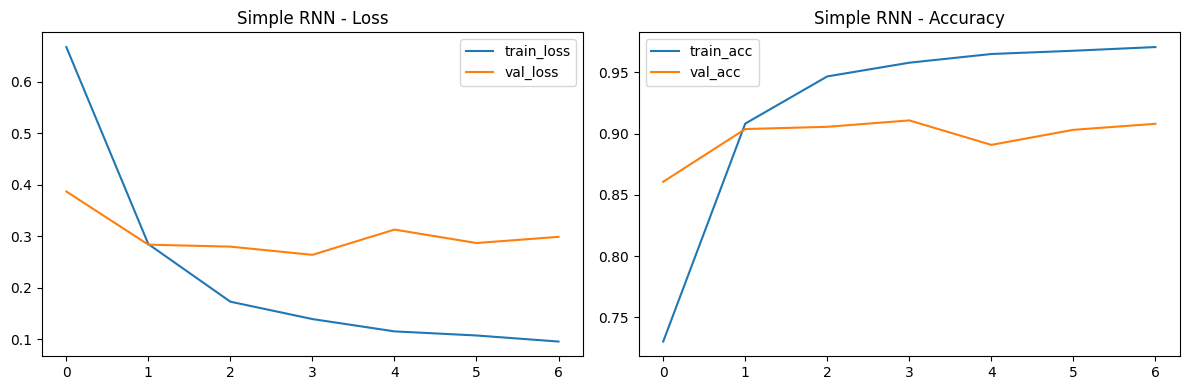

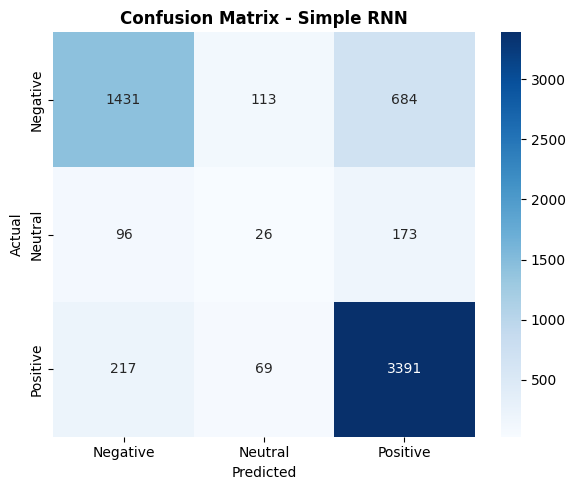

In [28]:
plot_training_curves(rnn_history, 'Simple RNN')
plot_confusion_matrix(y_test, predictions['Simple RNN'], 'Simple RNN')


## 9. النموذج الثاني: LSTM

In [29]:
tf.keras.backend.clear_session()

lstm_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(optimizer=Adam(learning_rate=1e-3),
                    loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
lstm_model, lstm_history = train_and_evaluate(lstm_model, 'LSTM')


Training: LSTM
Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.6772 - loss: 0.7512 - val_accuracy: 0.8039 - val_loss: 0.5414
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.8690 - loss: 0.4039 - val_accuracy: 0.8574 - val_loss: 0.3990
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9191 - loss: 0.2729 - val_accuracy: 0.8838 - val_loss: 0.3344
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9372 - loss: 0.2153 - val_accuracy: 0.8998 - val_loss: 0.3162
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9468 - loss: 0.1839 - val_accuracy: 0.9004 - val_loss: 0.3448
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9529 - loss: 0.1592 - val_accuracy: 0.9022 - val_loss: 0.3601
Epoch 7/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9554 - loss: 0.1470 - val_accuracy: 0.8936 - val_loss: 0.4095

Accuracy:  0.7974
Precision: 0.7839
Recall:    0.7974
F1-score:  0.7885

 

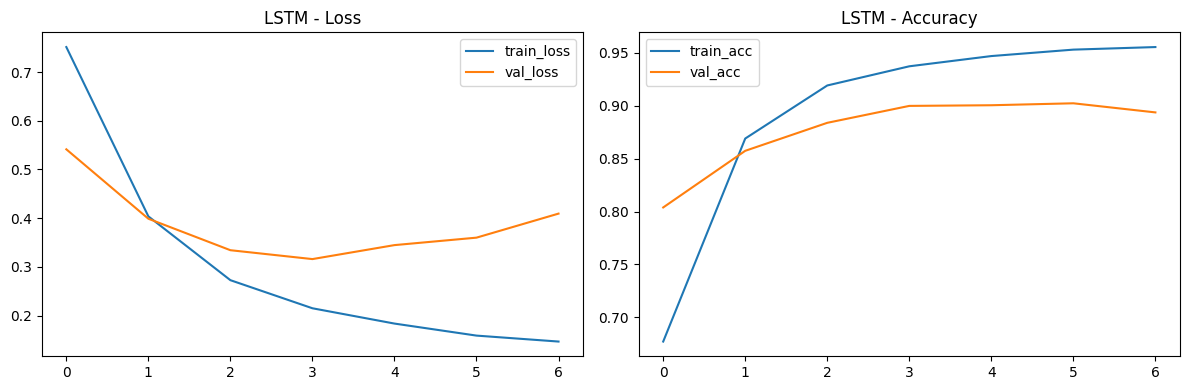

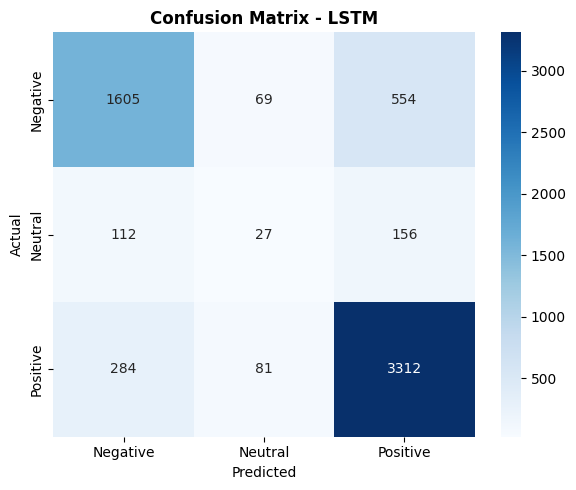

In [31]:
plot_training_curves(lstm_history, 'LSTM')
plot_confusion_matrix(y_test, predictions['LSTM'], 'LSTM')


## 10. النموذج الثالث: GRU

In [32]:
tf.keras.backend.clear_session()

gru_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GRU(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

gru_model.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
gru_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
gru_model, gru_history = train_and_evaluate(gru_model, 'GRU')


Training: GRU
Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.6036 - loss: 0.8531 - val_accuracy: 0.7538 - val_loss: 0.6068
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.8300 - loss: 0.4803 - val_accuracy: 0.8577 - val_loss: 0.3958
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9155 - loss: 0.2699 - val_accuracy: 0.8949 - val_loss: 0.3177
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9441 - loss: 0.1852 - val_accuracy: 0.9004 - val_loss: 0.3207
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.9548 - loss: 0.1446 - val_accuracy: 0.9041 - val_loss: 0.3208
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9616 - loss: 0.1228 - val_accuracy: 0.9026 - val_loss: 0.3563

Accuracy:  0.8029
Precision: 0.7937
Recall:    0.8029
F1-score:  0.7946

              precision    recall  f1-score   support

    Negative       0.83      0.71      0.77      2228
     Neutral       0.17

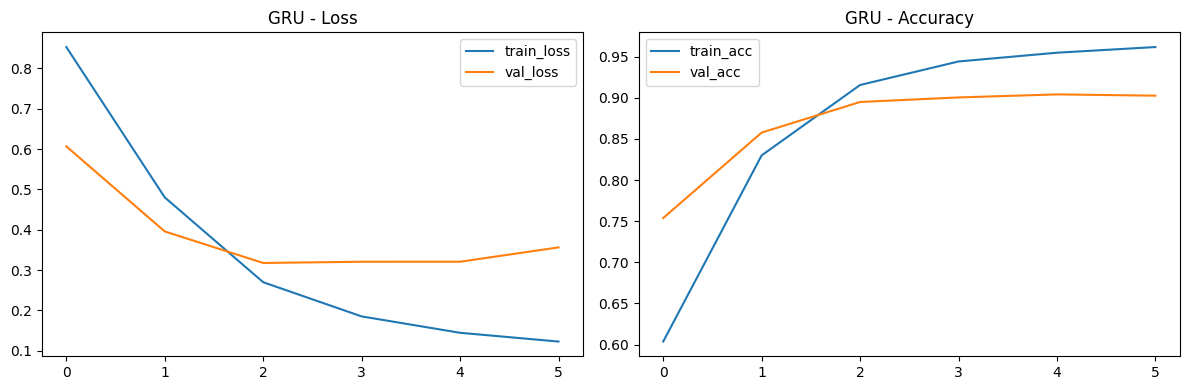

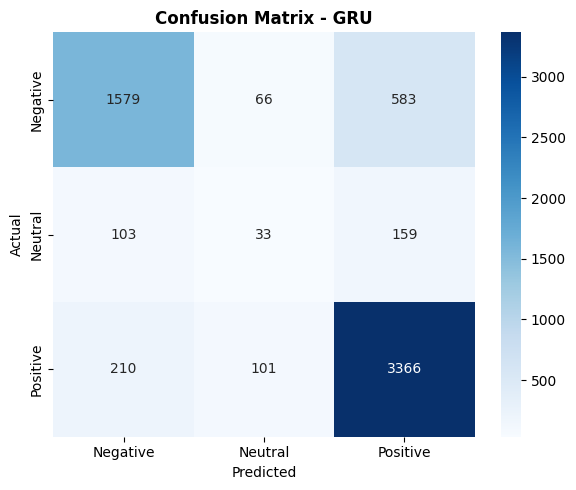

In [34]:
plot_training_curves(gru_history, 'GRU')
plot_confusion_matrix(y_test, predictions['GRU'], 'GRU')


## 11. النموذج الرابع: Bidirectional RNN (BiLSTM)

In [35]:
tf.keras.backend.clear_session()

bilstm_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

bilstm_model.compile(optimizer=Adam(learning_rate=1e-3),
                      loss='categorical_crossentropy', metrics=['accuracy'])
bilstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
bilstm_model, bilstm_history = train_and_evaluate(bilstm_model, 'Bidirectional RNN')


Training: Bidirectional RNN
Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.7541 - loss: 0.6143 - val_accuracy: 0.8684 - val_loss: 0.3678
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.9092 - loss: 0.2827 - val_accuracy: 0.8949 - val_loss: 0.3021
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9385 - loss: 0.1945 - val_accuracy: 0.9056 - val_loss: 0.2911
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9510 - loss: 0.1555 - val_accuracy: 0.9029 - val_loss: 0.3281
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9584 - loss: 0.1340 - val_accuracy: 0.9044 - val_loss: 0.3349
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9618 - loss: 0.1181 - val_accuracy: 0.9010 - val_loss: 0.3706

Accuracy:  0.7973
Precision: 0.7829
Recall:    0.7973
F1-score:  0.7863

              precision    recall  f1-score   support

    Negative       0.81      0.70      0.75      2228
     Neut

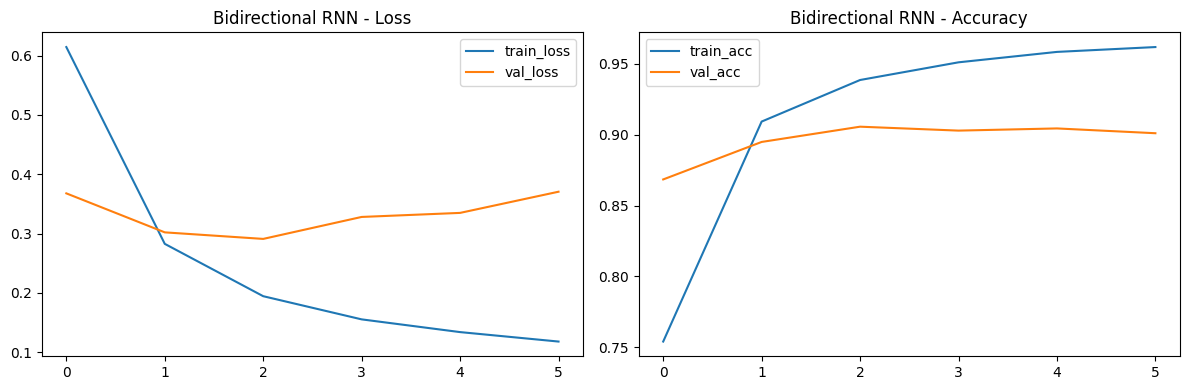

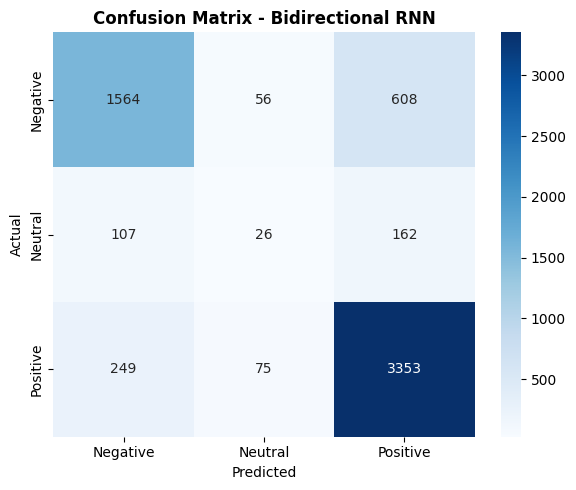

In [37]:
plot_training_curves(bilstm_history, 'Bidirectional RNN')
plot_confusion_matrix(y_test, predictions['Bidirectional RNN'], 'Bidirectional RNN')


## 12. النموذج الخامس: Transformer (Encoder مبني من الصفر)

مفيش إنترنت لتحميل نموذج Transformer جاهز (زي BERT)، فبنبني Transformer Encoder بسيط من الصفر باستخدام `MultiHeadAttention` الموجودة جوه Keras، مع Positional Embedding.

In [38]:
class PositionalEmbedding(Layer):
    def __init__(self, max_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embed_dim)
        self.max_len = max_len

    def call(self, x):
        positions = tf.range(start=0, limit=self.max_len, delta=1)
        return self.token_emb(x) + self.pos_emb(positions)


class TransformerEncoderBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, inputs, training=False):
        attn_out = self.att(inputs, inputs)
        attn_out = self.drop1(attn_out, training=training)
        out1 = self.norm1(inputs + attn_out)

        ffn_out = self.ffn(out1)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.norm2(out1 + ffn_out)


tf.keras.backend.clear_session()

EMBED_DIM_TR = 64
NUM_HEADS = 4
FF_DIM = 128

inputs = Input(shape=(MAX_LEN,))
x = PositionalEmbedding(MAX_LEN, vocab_size_actual, EMBED_DIM_TR)(inputs)
x = TransformerEncoderBlock(EMBED_DIM_TR, NUM_HEADS, FF_DIM, dropout=0.3)(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.4)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer=Adam(learning_rate=1e-3),
                           loss='categorical_crossentropy', metrics=['accuracy'])
transformer_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 27, 64)         │     1,281,728 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block       │ (None, 27, 64)         │        83,200 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,367,107 (5.22 MB)

 Trainable params: 1,367,107 (5.22 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
transformer_model, transformer_history = train_and_evaluate(transformer_model, 'Transformer')


Training: Transformer
Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 57s 116ms/step - accuracy: 0.6949 - loss: 0.7217 - val_accuracy: 0.8466 - val_loss: 0.4342
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 53s 116ms/step - accuracy: 0.9003 - loss: 0.3198 - val_accuracy: 0.8958 - val_loss: 0.3063
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 52s 113ms/step - accuracy: 0.9377 - loss: 0.2052 - val_accuracy: 0.8967 - val_loss: 0.3261
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.9496 - loss: 0.1591 - val_accuracy: 0.9010 - val_loss: 0.3736
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.9568 - loss: 0.1332 - val_accuracy: 0.9013 - val_loss: 0.4165

Accuracy:  0.8058
Precision: 0.7913
Recall:    0.8058
F1-score:  0.7956

              precision    recall  f1-score   support

    Negative       0.82      0.72      0.77      2228
     Neutral       0.17      0.09      0.12       295
    Positive       0.82      0.91      0.87      3677

    accuracy                   

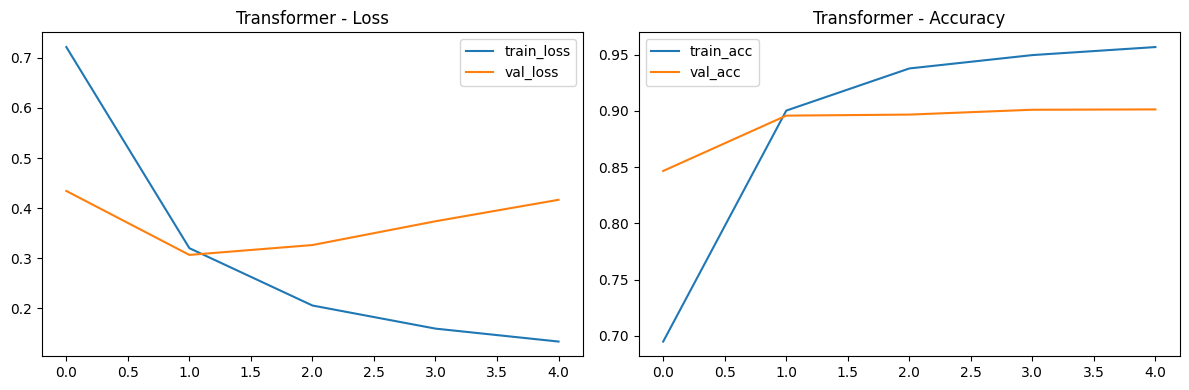

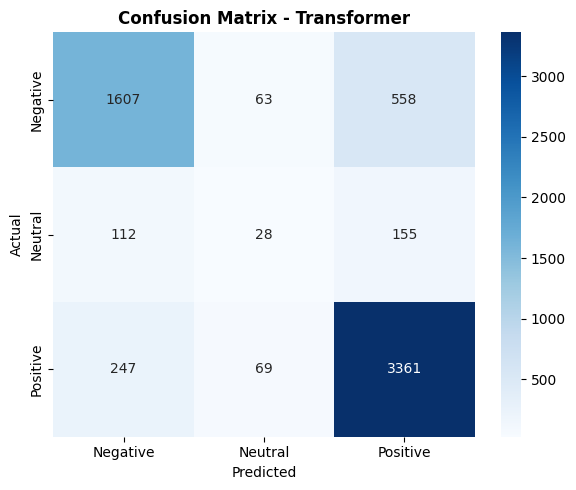

In [40]:
plot_training_curves(transformer_history, 'Transformer')
plot_confusion_matrix(y_test, predictions['Transformer'], 'Transformer')


## 13. المقارنة النهائية بين كل النماذج (Final Comparison)

                   accuracy  precision  recall      f1
Transformer          0.8058     0.7913  0.8058  0.7956
GRU                  0.8029     0.7937  0.8029  0.7946
LSTM                 0.7974     0.7839  0.7974  0.7885
Bidirectional RNN    0.7973     0.7829  0.7973  0.7863
Simple RNN           0.7819     0.7742  0.7819  0.7714


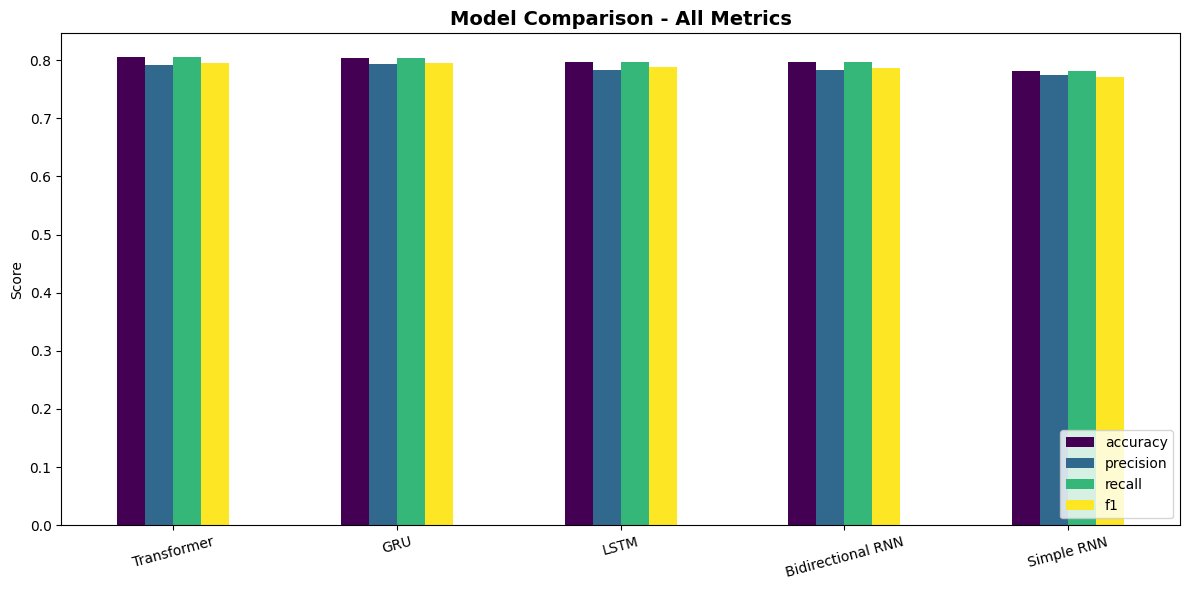


Best model based on weighted F1-score: Transformer


In [41]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('f1', ascending=False)
print(results_df.round(4))

results_df[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Model Comparison - All Metrics', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = results_df['f1'].idxmax()
print(f"\nBest model based on weighted F1-score: {best_model_name}")


### Confusion Matrices لكل النماذج مجمّعة في شكل واحد

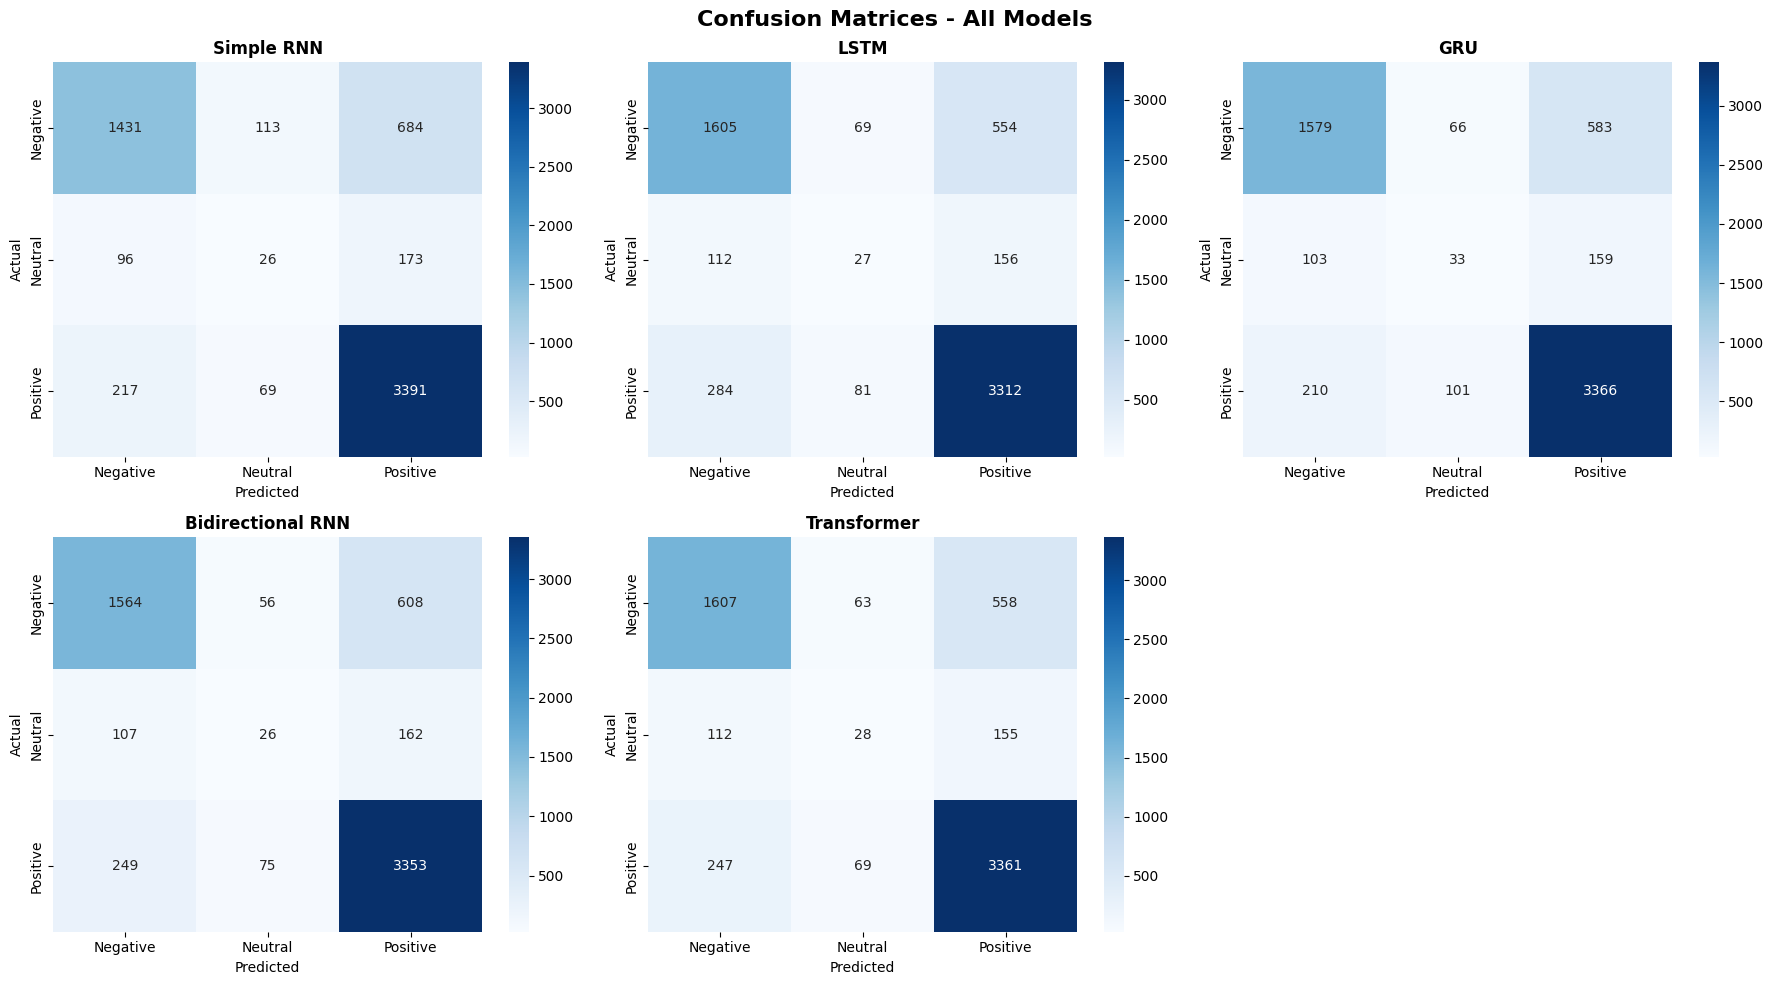

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# hide unused subplot(s)
for ax in axes[len(predictions):]:
    ax.axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. الخلاصة (Conclusion)

- تم تجربة 5 معماريات مختلفة: `Simple RNN`, `LSTM`, `GRU`, `Bidirectional RNN`, و `Transformer` (مبني من الصفر) على نفس بيانات المشاعر العربية.
- كل النماذج استخدمت نفس الـ preprocessing pipeline (تنظيف، تطبيع الحروف، إزالة تشكيل، إزالة stopwords) ونفس الـ class weights لمعالجة عدم توازن الفئات.
- شوف جدول `results_df` فوق عشان تقارن الدقة (Accuracy) والـ F1-score لكل نموذج، وشوف الـ Confusion Matrices عشان تفهم مين بيغلط في أنهي فئة أكتر (غالبًا الفئة المحايدة (Neutral) هي الأصعب لأنها الأقرب في المعنى للفئتين التانيين).

